# Работа с временным признаком

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
df = pd.read_csv('clean_data_part_1.csv')
df.drop('Unnamed: 0', axis=1, inplace=True)
df.head(3)

,user_id,timestamp,group,landing_page,converted
0,922696,2025-01-02 13:42:05.378582,treatment,new_page,0
1,781507,2025-01-02 13:42:15.234051,control,old_page,0
2,737319,2025-01-02 13:42:21.786186,control,old_page,0


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 287706 entries, 0 to 287705
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       287706 non-null  int64 
 1   timestamp     287706 non-null  object
 2   group         287706 non-null  object
 3   landing_page  287706 non-null  object
 4   converted     287706 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.0+ MB


## Оценим распределение выбранной метрики - CR по дням

**Сначала без разделения на группы**

In [102]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [103]:
cr_per_day = df.groupby([df['timestamp'].dt.date])['converted'].mean().reset_index()
cr_per_day

,timestamp,converted
0,2025-01-02,0.122532
1,2025-01-03,0.113584
2,2025-01-04,0.119428
3,2025-01-05,0.119096
4,2025-01-06,0.119182
5,2025-01-07,0.118833
6,2025-01-08,0.119952
7,2025-01-09,0.119040
8,2025-01-10,0.119864
9,2025-01-11,0.116794


Используем среднее для визуализации

In [104]:
cr_mean_value = cr_per_day['converted'].mean()
print(f'Среднее значение CR за все дни равно = {cr_mean_value}')

Среднее значение CR за все дни равно = 0.11959453863167503


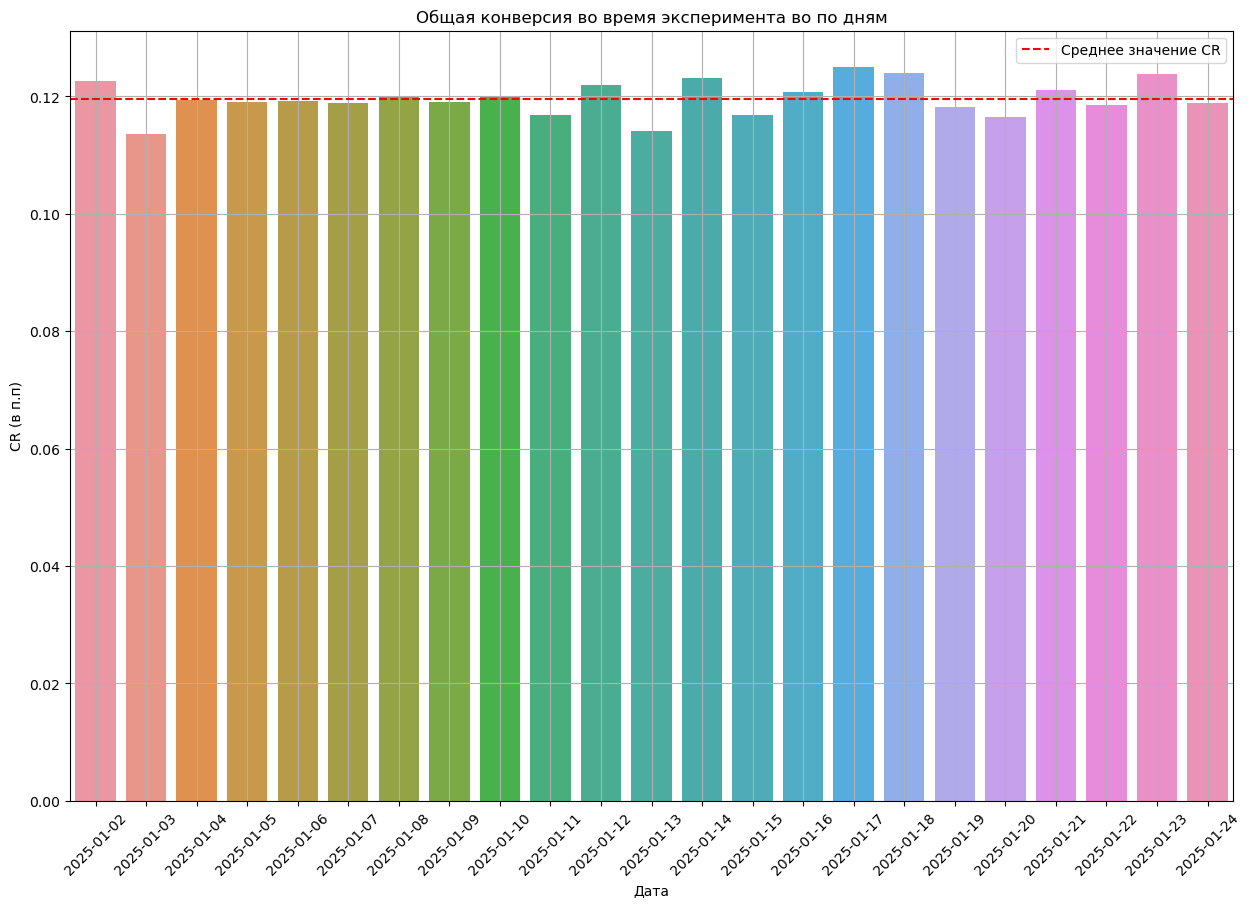

In [105]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.axhline(
    cr_mean_value, 
    color = 'red',
    linestyle = '--',
    label = 'Среднее значение CR'
)


sns.barplot(
    data = cr_per_day,
    x = 'timestamp',
    y = 'converted',
    ax = ax
)


plt.xticks(rotation=45)

ax.set_title('Общая конверсия во время эксперимента во по дням')
ax.set_xlabel('Дата')
ax.set_ylabel('CR (в п.п)')

plt.legend()
plt.grid()
plt.show()

**Видимых различий нет, тогда посмотрим на дельту день/день**

In [106]:
cr_per_day['delta'] = cr_per_day['converted'].diff()
cr_per_day

,timestamp,converted,delta
0,2025-01-02,0.122532,NaN
1,2025-01-03,0.113584,-0.008947
2,2025-01-04,0.119428,0.005844
3,2025-01-05,0.119096,-0.000332
4,2025-01-06,0.119182,0.000086
5,2025-01-07,0.118833,-0.000349
6,2025-01-08,0.119952,0.001119
7,2025-01-09,0.119040,-0.000912
8,2025-01-10,0.119864,0.000824
9,2025-01-11,0.116794,-0.003070


Выведем на график минимальную и максимальную дельту

In [107]:
min_delta_per_day = cr_per_day['delta'].min()
max_delta_per_day = cr_per_day['delta'].max()

print(min_delta_per_day, max_delta_per_day)

-0.008947346973796066 0.009028188082238486


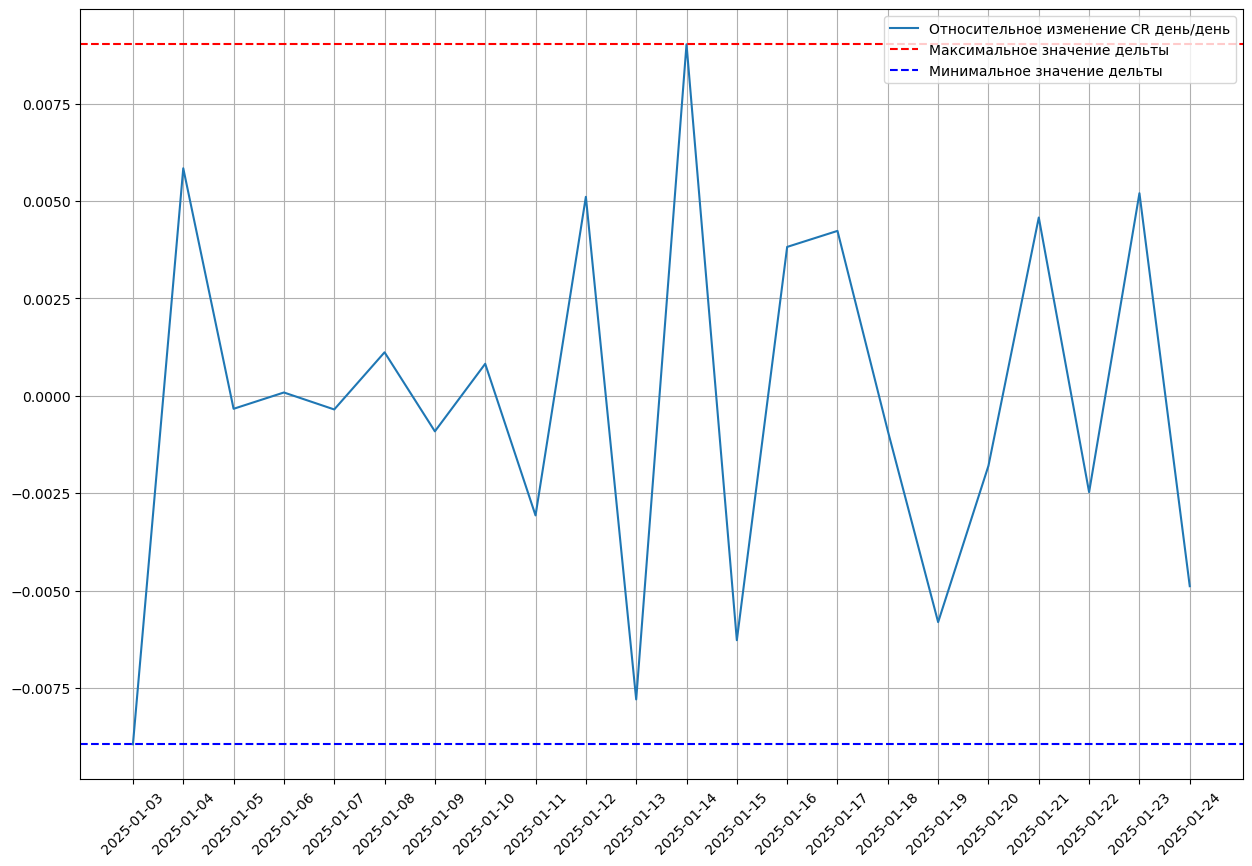

In [108]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.plot(
    cr_per_day['timestamp'][1:],
    cr_per_day['delta'][1:],
    label = 'Относительное изменение CR день/день'
)

ax.axhline(
    max_delta_per_day, 
    color = 'red',
    linestyle = '--',
    label = 'Максимальное значение дельты'
)

ax.axhline(
    min_delta_per_day, 
    color = 'blue',
    linestyle = '--',
    label = 'Минимальное значение дельты'
)

plt.xticks(cr_per_day['timestamp'][1: ], rotation=45)

plt.legend()
plt.grid()
plt.show()

**Проделаем аналогичное с часами**

In [109]:
cr_per_hour = df.groupby([df['timestamp'].dt.hour])['converted'].mean().reset_index()
cr_per_hour

,timestamp,converted
0,0,0.120796
1,1,0.113713
2,2,0.113791
3,3,0.114443
4,4,0.114470
5,5,0.121042
6,6,0.121045
7,7,0.117618
8,8,0.118823
9,9,0.124958


In [110]:
cr_mean_value = cr_per_hour['converted'].mean()
print(f'Среднее значение CR за все часы = {cr_mean_value}')

Среднее значение CR за все часы = 0.11953753954859485


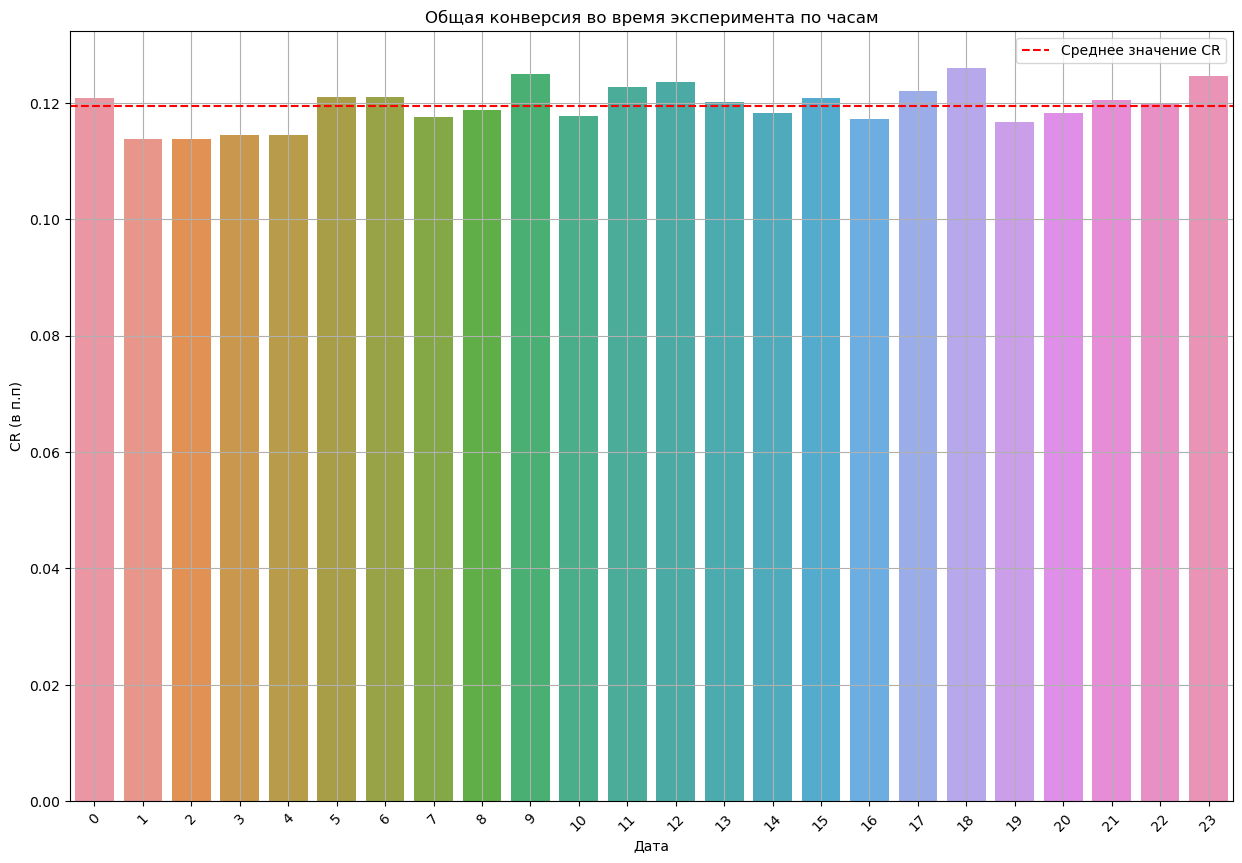

In [111]:
fig, ax = plt.subplots(figsize=(15, 10))

ax.axhline(
    cr_mean_value, 
    color = 'red',
    linestyle = '--',
    label = 'Среднее значение CR'
)


sns.barplot(
    data = cr_per_hour,
    x = 'timestamp',
    y = 'converted',
    ax = ax
)


plt.xticks(rotation=45)

ax.set_title('Общая конверсия во время эксперимента по часам')
ax.set_xlabel('Дата')
ax.set_ylabel('CR (в п.п)')

plt.legend()
plt.grid()
plt.show()

**Сделаем 1 график из предыдущих**

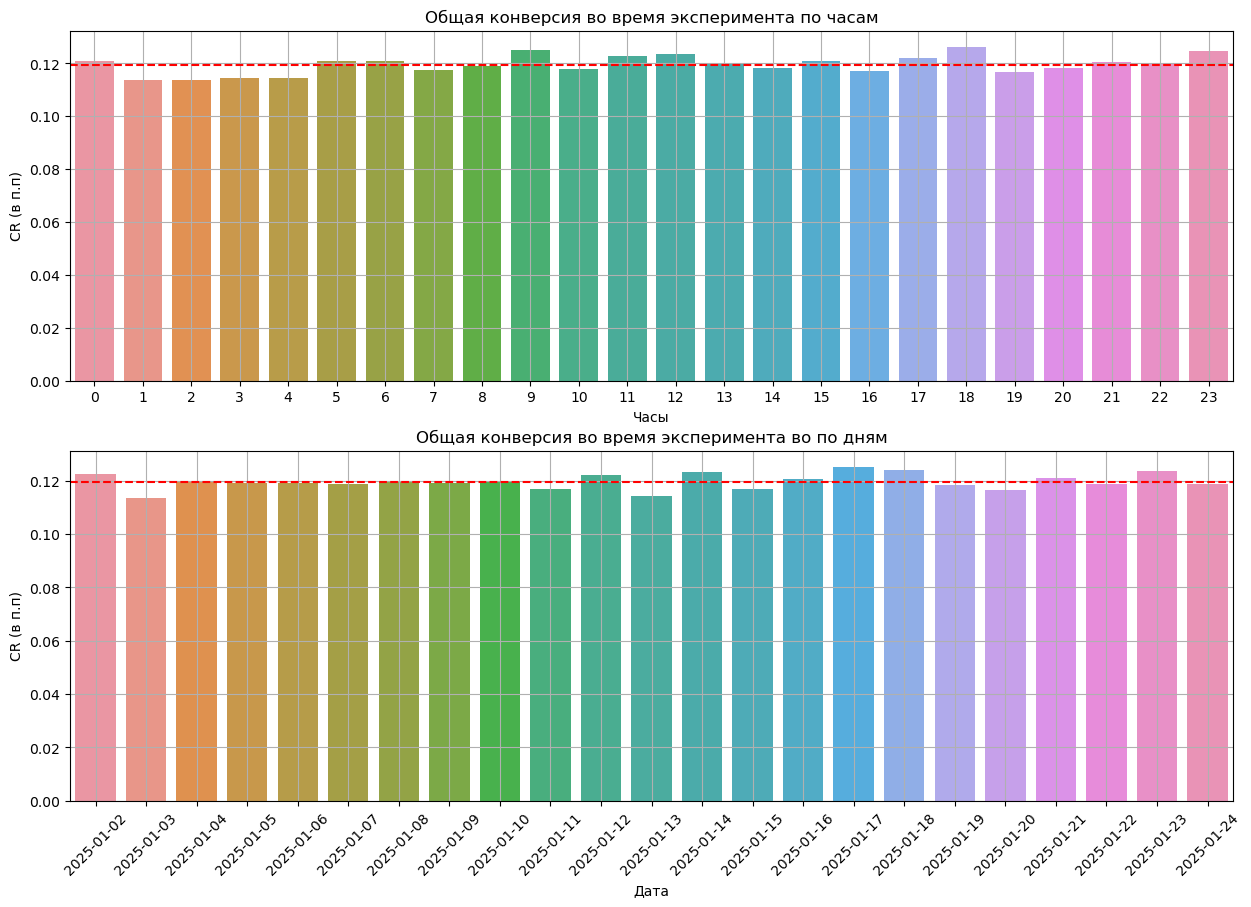

In [112]:
fig, (ax_0, ax_1) = plt.subplots(2, figsize=(15, 10))


ax_0.axhline(
    cr_mean_value, 
    color = 'red',
    linestyle = '--',
    label = 'Среднее значение CR'
)

sns.barplot(
    data = cr_per_hour,
    x = 'timestamp',
    y = 'converted',
    ax = ax_0
)

ax_0.set_title('Общая конверсия во время эксперимента по часам')
ax_0.set_xlabel('Часы')
ax_0.set_ylabel('CR (в п.п)')
ax_0.grid()



ax_1.axhline(
    cr_mean_value, 
    color = 'red',
    linestyle = '--',
    label = 'Среднее значение CR'
)

sns.barplot(
    data = cr_per_day,
    x = 'timestamp',
    y = 'converted',
    ax = ax_1
)

ax_1.set_title('Общая конверсия во время эксперимента во по дням')
ax_1.set_xlabel('Дата')
ax_1.set_ylabel('CR (в п.п)')
ax_1.grid()
plt.setp(ax_1.get_xticklabels(), rotation=45)

plt.show()

**Теперь будем смотреть на конверсию по группам**

In [113]:
compare_of_groups_cr_date = df.groupby([df['timestamp'].dt.date, 'group'])['converted'].mean().reset_index()
compare_of_groups_cr_date

,timestamp,group,converted
0,2025-01-02,control,0.125618
1,2025-01-02,treatment,0.119450
2,2025-01-03,control,0.113352
3,2025-01-03,treatment,0.113816
4,2025-01-04,control,0.121974
5,2025-01-04,treatment,0.116867
6,2025-01-05,control,0.123273
7,2025-01-05,treatment,0.114980
8,2025-01-06,control,0.114851
9,2025-01-06,treatment,0.123431


Сразу сделаем почасовой анализ

In [114]:
compare_of_groups_cr_hour = df.groupby([df['timestamp'].dt.hour, 'group'])['converted'].mean().reset_index()
compare_of_groups_cr_hour

,timestamp,group,converted
0,0,control,0.121046
1,0,treatment,0.120551
2,1,control,0.116249
3,1,treatment,0.111111
4,2,control,0.114019
5,2,treatment,0.113560
6,3,control,0.114251
7,3,treatment,0.114624
8,4,control,0.121268
9,4,treatment,0.107578


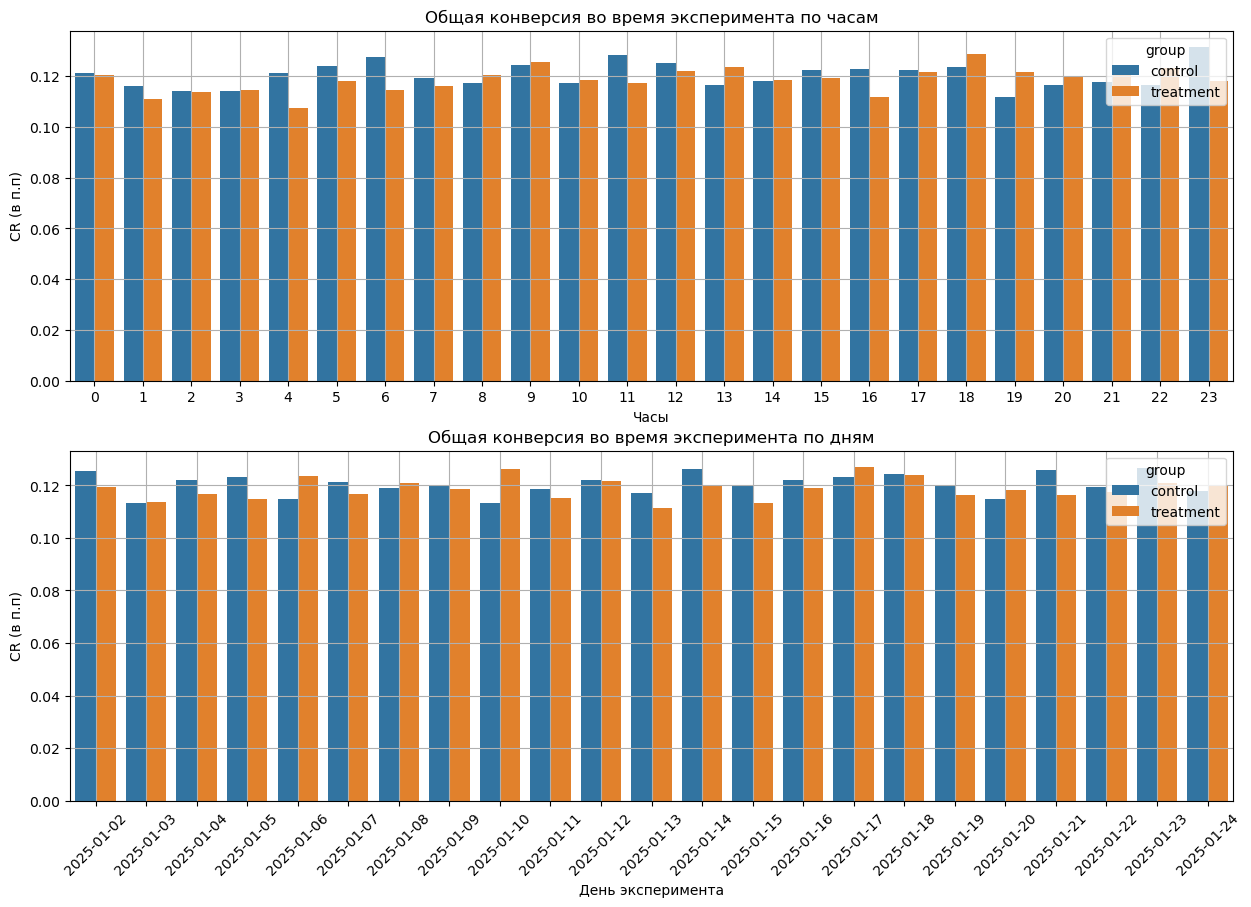

In [ ]:
fig, (ax_0, ax_1) = plt.subplots(2, figsize=(15, 10))

sns.barplot(
    data = compare_of_groups_cr_hour,
    x = 'timestamp',
    y = 'converted',
    hue = 'group',
    ax = ax_0
)

ax_0.set_title('Общая конверсия во время эксперимента по часам')
ax_0.set_xlabel('Часы')
ax_0.set_ylabel('CR (в п.п)')
ax_0.grid()


sns.barplot(
    data = compare_of_groups_cr_date,
    x = 'timestamp',
    y = 'converted',
    hue = 'group',
    ax = ax_1
)

ax_1.set_title('Общая конверсия во время эксперимента по дням')
ax_1.set_xlabel('День эксперимента')
ax_1.set_ylabel('CR (в п.п)')
ax_1.grid()
plt.setp(ax_1.get_xticklabels(), rotation=45)

plt.show()

Вывод: можно заметить, что часовой паттерн повторяет дневной - нет изменения как в группах, поэтому можно подробнее посмотреть на изменение конверсий между группами день/день.

Для создания графика из нескольких, в частности метода add_subplots:
- https://www.geeksforgeeks.org/python/plot-multiple-plots-in-matplotlib/
- https://www.geeksforgeeks.org/python/matplotlib-figure-figure-add_subplot-in-python/

In [117]:
control_group = compare_of_groups_cr_date[compare_of_groups_cr_date['group'] == 'control'].reset_index(drop = True)
treatment_group = compare_of_groups_cr_date[compare_of_groups_cr_date['group'] == 'treatment'].reset_index(drop = True)


control_group

,timestamp,group,converted
0,2025-01-02,control,0.125618
1,2025-01-03,control,0.113352
2,2025-01-04,control,0.121974
3,2025-01-05,control,0.123273
4,2025-01-06,control,0.114851
5,2025-01-07,control,0.121138
6,2025-01-08,control,0.119144
7,2025-01-09,control,0.119598
8,2025-01-10,control,0.113368
9,2025-01-11,control,0.118473


Посчитаем дельты

In [127]:
control_group['delta'] = control_group['converted'].diff()
treatment_group['delta'] = treatment_group['converted'].diff()

control_group

,timestamp,group,converted,delta
0,2025-01-02,control,0.125618,NaN
1,2025-01-03,control,0.113352,-0.012266
2,2025-01-04,control,0.121974,0.008622
3,2025-01-05,control,0.123273,0.001299
4,2025-01-06,control,0.114851,-0.008421
5,2025-01-07,control,0.121138,0.006286
6,2025-01-08,control,0.119144,-0.001994
7,2025-01-09,control,0.119598,0.000454
8,2025-01-10,control,0.113368,-0.006231
9,2025-01-11,control,0.118473,0.005105


Найдем разницу между группами в каждом дне

In [130]:
delta_in_day = treatment_group['converted'] - control_group['converted']
delta_in_day

0    -0.006167
1     0.000465
2    -0.005107
3    -0.008293
4     0.008579
5    -0.004603
6     0.001613
7    -0.001117
8     0.012950
9    -0.003362
10   -0.000347
11   -0.005665
12   -0.006092
13   -0.006985
14   -0.003044
15    0.003805
16   -0.000235
17   -0.004101
18    0.003443
19   -0.009573
20   -0.001747
21   -0.005599
22    0.001966
Name: converted, dtype: float64

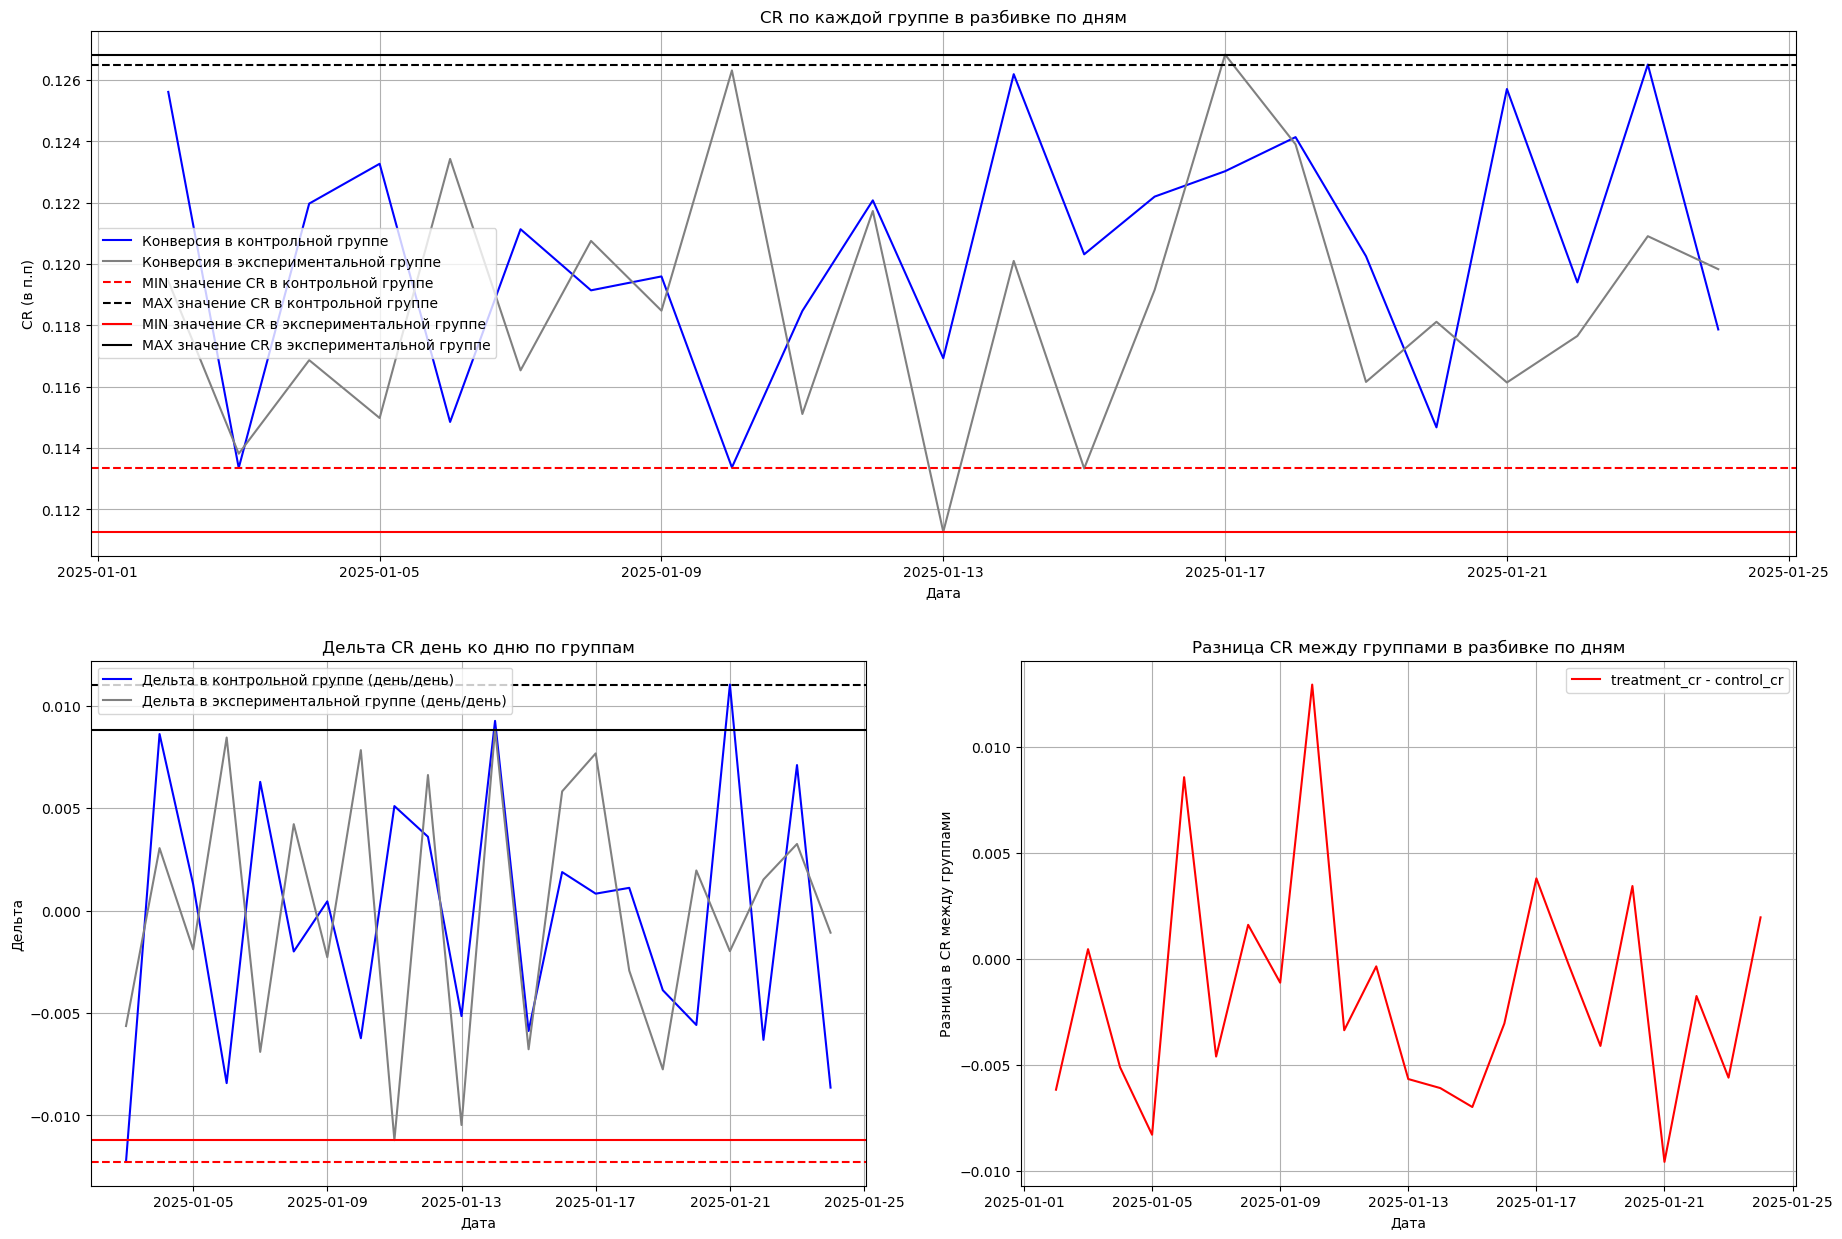

In [150]:
fig = plt.figure(figsize=(22, 15))

ax_0 = fig.add_subplot(2, 1, 1)
ax_1 = fig.add_subplot(2, 2, 3)
ax_2 = fig.add_subplot(2, 2, 4)



ax_0.plot(
    control_group['timestamp'],
    control_group['converted'],
    color = 'blue',
    label ='Конверсия в контрольной группе'
)
ax_0.plot(
    treatment_group['timestamp'],
    treatment_group['converted'],
    color = 'grey',
    label ='Конверсия в экспериментальной группе'
)

ax_0.axhline(
    control_group['converted'].min(),
    color = 'red',
    linestyle = '--',
    label = 'MIN значение CR в контрольной группе'
)
ax_0.axhline(
    control_group['converted'].max(),
    color = 'black',
    linestyle = '--',
    label = 'MAX значение CR в контрольной группе'
)
ax_0.axhline(
    treatment_group['converted'].min(),
    color = 'red',
    label = 'MIN значение CR в экспериментальной группе'
)
ax_0.axhline(
    treatment_group['converted'].max(),
    color = 'black',
    label = 'MAX значение CR в экспериментальной группе'
)
ax_0.set_title('CR по каждой группе в разбивке по дням')
ax_0.set_xlabel('Дата')
ax_0.set_ylabel('CR (в п.п)')
ax_0.grid()
ax_0.legend()



ax_1.plot(
    control_group['timestamp'][1: ],
    control_group['delta'][1: ],
    color = 'blue',
    label ='Дельта в контрольной группе (день/день)'
)
ax_1.plot(
    treatment_group['timestamp'][1: ],
    treatment_group['delta'][1: ],
    color = 'grey',
    label ='Дельта в экспериментальной группе (день/день)'
)

ax_1.axhline(
    control_group['delta'].min(),
    color = 'red',
    linestyle = '--',
    # label = 'MIN значение CR в контрольной группе'
)
ax_1.axhline(
    control_group['delta'].max(),
    color = 'black',
    linestyle = '--',
    # label = 'MAX значение CR в контрольной группе'
)
ax_1.axhline(
    treatment_group['delta'].min(),
    color = 'red',
    # label = 'MIN значение CR в экспериментальной группе'
)
ax_1.axhline(
    treatment_group['delta'].max(),
    color = 'black',
    # label = 'MAX значение CR в экспериментальной группе'
)

ax_1.set_title('Дельта CR день ко дню по группам')
ax_1.set_xlabel('Дата')
ax_1.set_ylabel('Дельта')
ax_1.grid()
ax_1.legend()



ax_2.plot(
    control_group['timestamp'],
    delta_in_day,
    color = 'red',
    label ='treatment_cr - control_cr'
)
ax_2.set_title('Разница CR между группами в разбивке по дням')
ax_2.set_xlabel('Дата')
ax_2.set_ylabel('Разница в CR между группами')
ax_2.grid()
ax_2.legend()


plt.show()

Вывод: эффекта новизны нет, тенденции у обоих групп схожие. Конверсия у экспериментальной группы хуже, чем у контрольной.